In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df= pd.read_csv(r"D:/ML/DataSet/weight-height.csv")

In [3]:
df.sample(5)

,Gender,Height,Weight
8245,Female,65.158091,148.361308
7623,Female,68.035907,152.125021
3238,Male,67.396783,179.573295
5721,Female,59.001742,102.478665
5415,Female,64.687591,124.728487


we will be working on numerical columns obviously

### First lets focus on height column

In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\Asus\AppData\Local\Temp\ipykernel_30784\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

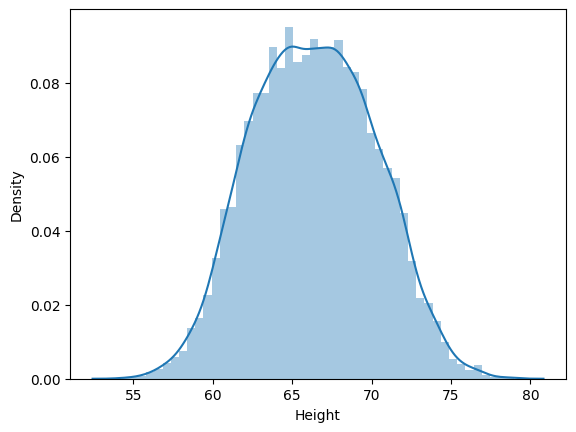

In [6]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

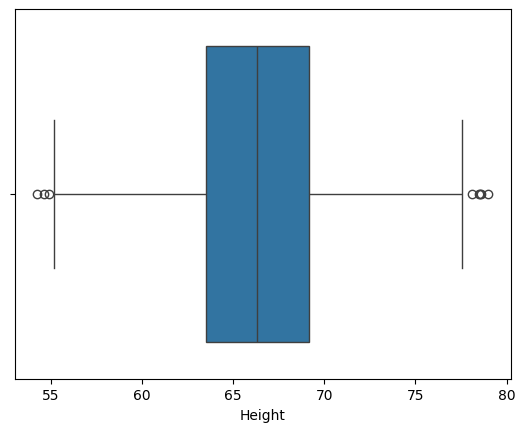

In [9]:
sns.boxplot(x=df['Height']) #here, we can see that we have outliers from both sides

In [10]:
upper_limit = df['Height'].quantile(0.9875)
lower_limit = df['Height'].quantile(0.01)

In [11]:
upper_limit

np.float64(74.52107811802159)

In [12]:
lower_limit

np.float64(58.13441158671655)

In [13]:
df[(df['Height']>=74.521)|(df['Height']<=58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [15]:
new_df=df[(df['Height']<=74.521)&(df['Height']>=58.13)]

In [16]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [17]:
new_df.describe()

,Height,Weight
count,9775.000000,9775.000000
mean,66.343160,161.247425
std,3.625500,30.821474
min,58.134496,77.523774
25%,63.571564,136.250594
50%,66.308373,161.061365
75%,69.097954,186.579081
max,74.520972,241.893563


C:\Users\Asus\AppData\Local\Temp\ipykernel_30784\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

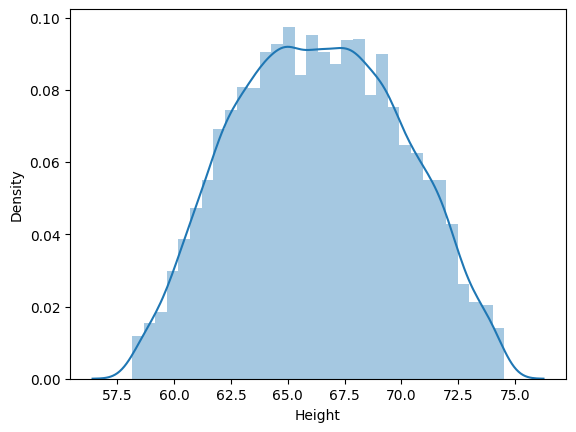

In [18]:
sns.distplot(new_df['Height'])

<Axes: xlabel='Height'>

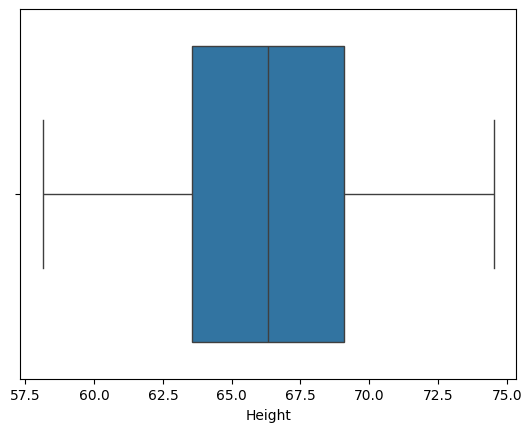

In [21]:
sns.boxplot(x=new_df['Height'])     #outliers have been removed

till now we have seen that how the trimmig is done in this method of using percentile to detect outlier

now we will study : 

## Capping or Winsorization

In [23]:
df['Height'] = np.where(
    df['Height']>=upper_limit,
    upper_limit,
    np.where(
        df['Height']<=lower_limit,
        lower_limit,
        df['Height'],
    )
)

In [24]:
df.shape

(10000, 3)

In [25]:
df['Height'].describe()

count    10000.000000
mean        66.363297
std          3.789200
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.521078
Name: Height, dtype: float64

C:\Users\Asus\AppData\Local\Temp\ipykernel_30784\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

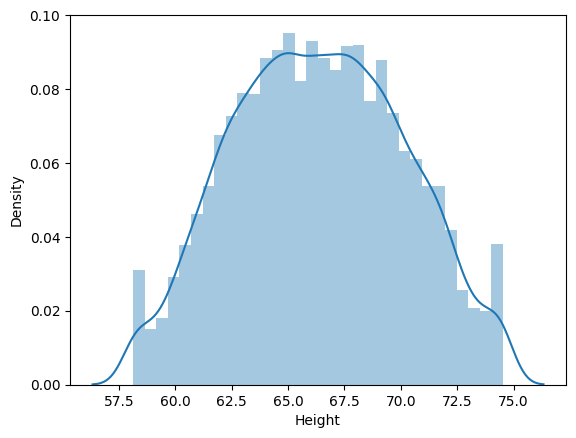

In [26]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

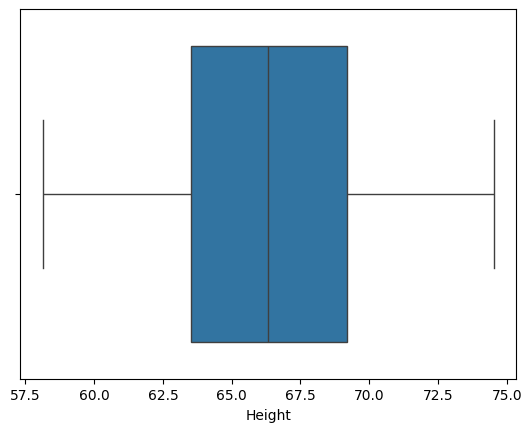

In [28]:
sns.boxplot(x=df['Height'])

----